# Bertopic Entropy 비율변화와 관련하여

In [1]:
# pip install bar_chart_race

In [2]:
import sys, os
p = os.path.abspath('../..')
sys.path.insert(1, p)

In [3]:
from gc import collect

import pickle
import lib.stats.stats as st
from utils.statistics import *
from utils.settings import set_matplotlib
from utils.distribution_collector import (collect_topic_distributions,
                                get_top_and_bottom_topics,
                                extract_specific_topics)
from constants import CONSTANTS
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib as mpl

import psycopg2
# from utils.statistics import *
import config.config as conf
import datetime
import re
# 포뮬러 구성
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd



In [4]:
from matplotlib import font_manager
import matplotlib as mpl
from matplotlib import font_manager as fm

# 설치된 폰트 이름과 경로 확인
for font in font_manager.fontManager.ttflist:
    if 'Helvetica' in font.name: # 'Nanum' 대신 원하는 글꼴의 일부를 입력하여 검색할 수 있습니다.
        print(font.name, font.fname)

# 직접 경로로 Helvetica 폰트 불러오기
font_path = "/System/Library/Fonts/Helvetica.ttc"
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()
print(f"Registered font name: {font_name}")

mpl.rcParams['font.family'] = font_name


Helvetica /System/Library/Fonts/Helvetica.ttc
Helvetica Neue /System/Library/Fonts/HelveticaNeue.ttc
Registered font name: Helvetica


In [5]:
data_dir = f'../../../so_pjt_src/{CONSTANTS.bert_monthly_data_dir_3[3:]}'
output_dir = './fig/'
date_range = 'Weekly'
model = 'BERT'

In [6]:
lst = os.listdir(data_dir)
df = pd.DataFrame()
# 디렉토리 내의 파일을 for 문으로 반복
for i in lst:
	js = load_json(f'{data_dir}/{i}')
	tmp = pd.DataFrame(js)
	tmp['json'] = i
	df = pd.concat([df, tmp], axis = 0)

In [7]:
df = df[['id', 'creationdate', 'Topic', 'json']].copy()

In [8]:
df['creationdate'] = pd.to_datetime(df['creationdate'], format="mixed")
df['cdate'] = pd.to_datetime(df['creationdate'], format="%Y-%m-%d").dt.date
df['cdate'] = pd.to_datetime(df['cdate'], format="%Y-%m-%d")


In [9]:
snap1_df = df[(df['cdate']>  CONSTANTS.start_date_snap1) & (df['cdate']< CONSTANTS.end_date_snap1)]
snap2_df = df[(df['cdate']>= CONSTANTS.start_date_snap2) & (df['cdate']< CONSTANTS.end_date_snap2)]
tot_df   = df[(df['cdate']>= CONSTANTS.start_date_snap1) & (df['cdate']< CONSTANTS.end_date_snap2)]

In [10]:
bf_gpt = df[(df['cdate']>  CONSTANTS.start_date_snap1) & (df['cdate']< CONSTANTS.std_date_snap1)]
topic_list = list(bf_gpt.groupby('Topic')['id'].count().reset_index().sort_values(by = 'id', ascending=False)['Topic'])

top10list = topic_list[:10]
bot10list = topic_list[-10:]
mid10list = np.setdiff1d(np.setdiff1d(np.arange(0, 50), top10list), bot10list)



In [11]:
snap1_df.loc[:, 'rel_week'] = np.floor((snap1_df['cdate']-\
                       CONSTANTS.std_date_snap1).dt.days/7) 
snap2_df.loc[:, 'rel_week'] = np.floor((snap2_df['cdate']-\
                       CONSTANTS.std_date_snap2).dt.days/7) 
tot_df.loc[:, 'rel_week'] = np.floor((tot_df['cdate']-\
                       CONSTANTS.std_date_snap1).dt.days/7) 

/var/folders/lk/t243gzpx379bzd9mvx8dcsmm0000gp/T/ipykernel_80692/3386300694.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snap1_df.loc[:, 'rel_week'] = np.floor((snap1_df['cdate']-\
/var/folders/lk/t243gzpx379bzd9mvx8dcsmm0000gp/T/ipykernel_80692/3386300694.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  snap2_df.loc[:, 'rel_week'] = np.floor((snap2_df['cdate']-\
/var/folders/lk/t243gzpx379bzd9mvx8dcsmm0000gp/T/ipykernel_80692/3386300694.py:5: SettingWithCopyWarning: 
A value is trying to be set o

In [12]:
tot_df.sort_values(by = ['cdate']).reset_index(drop=True, inplace=True)

In [13]:
tot_df = tot_df[(tot_df['rel_week']>=-52)&(tot_df['rel_week']<104)]

In [14]:
def get_list_topic(df, type='rel_week'):
    topic_range = np.arange(0,50)
    topic_dict = dict()

    if type =='rel_week':
        w_list = list(df[type].values)

        for w in w_list : 
            topic_dict[w] = {}
            tmp = df[df[type] == w]
            tmp = tmp.sort_values(by = ['pct'], ascending=False)
            top_list = list(tmp['Topic'][:10])
            bottom_list = list(tmp['Topic'][-10:])
            mid_list = list(np.setdiff1d(np.setdiff1d(np.arange(0, 50), top_list), bottom_list))
            
            topic_dict[w]['Top 20% Topics'] = top_list
            topic_dict[w]['Bottom 20% Topics'] = bottom_list
            topic_dict[w]['Mid 60% Topics'] = mid_list

    return topic_dict

In [15]:
def proportion_calc(df):
    df_tot = df.groupby('rel_week').count()['id'].reset_index(name = 'tot_cnt')
    df_topic = df.groupby(['rel_week', 'Topic']).count()['id'].reset_index(name = 'cnt')
    df_topic_r = pd.merge(df_topic, df_tot, on = 'rel_week')
    df_topic_r['pct'] = df_topic_r['cnt']/df_topic_r['tot_cnt']
    return df_topic_r


In [16]:
snap1       = proportion_calc(snap1_df)
snap2       = proportion_calc(snap2_df)
tot         = proportion_calc(tot_df)

In [17]:
snap1_topic_dict    = get_list_topic(snap1)
snap2_topic_dict    = get_list_topic(snap2)
tot_topic_dict      = get_list_topic(tot)

In [22]:
top_dict = {}
mid_dict = {}
bot_dict = {}
for key, value_dict in tot_topic_dict.items():
    top_dict[key] = value_dict['Top 20% Topics']
    mid_dict[key] = value_dict['Mid 60% Topics']
    bot_dict[key] = value_dict['Bottom 20% Topics']

In [ ]:
top10list = topic_list[:10]
bot10list = topic_list[-10:]
mid10list = np.setdiff1d(np.setdiff1d(np.arange(0, 50), top10list), bot10list)

In [23]:
top_rank_dict = dict()
bot_rank_dict = dict()
for rank in range(0, 10):
    top_rank_dict[rank] = [x[rank] for x in top_dict.values()]
    bot_rank_dict[rank] = [x[rank] for x in bot_dict.values()]

In [24]:
mid_rank_dict = dict()
for rank in range(0, 30):
    mid_rank_dict[rank] = [x[rank] for x in mid_dict.values()]

Text(0.02, 0.5, 'Topic number')

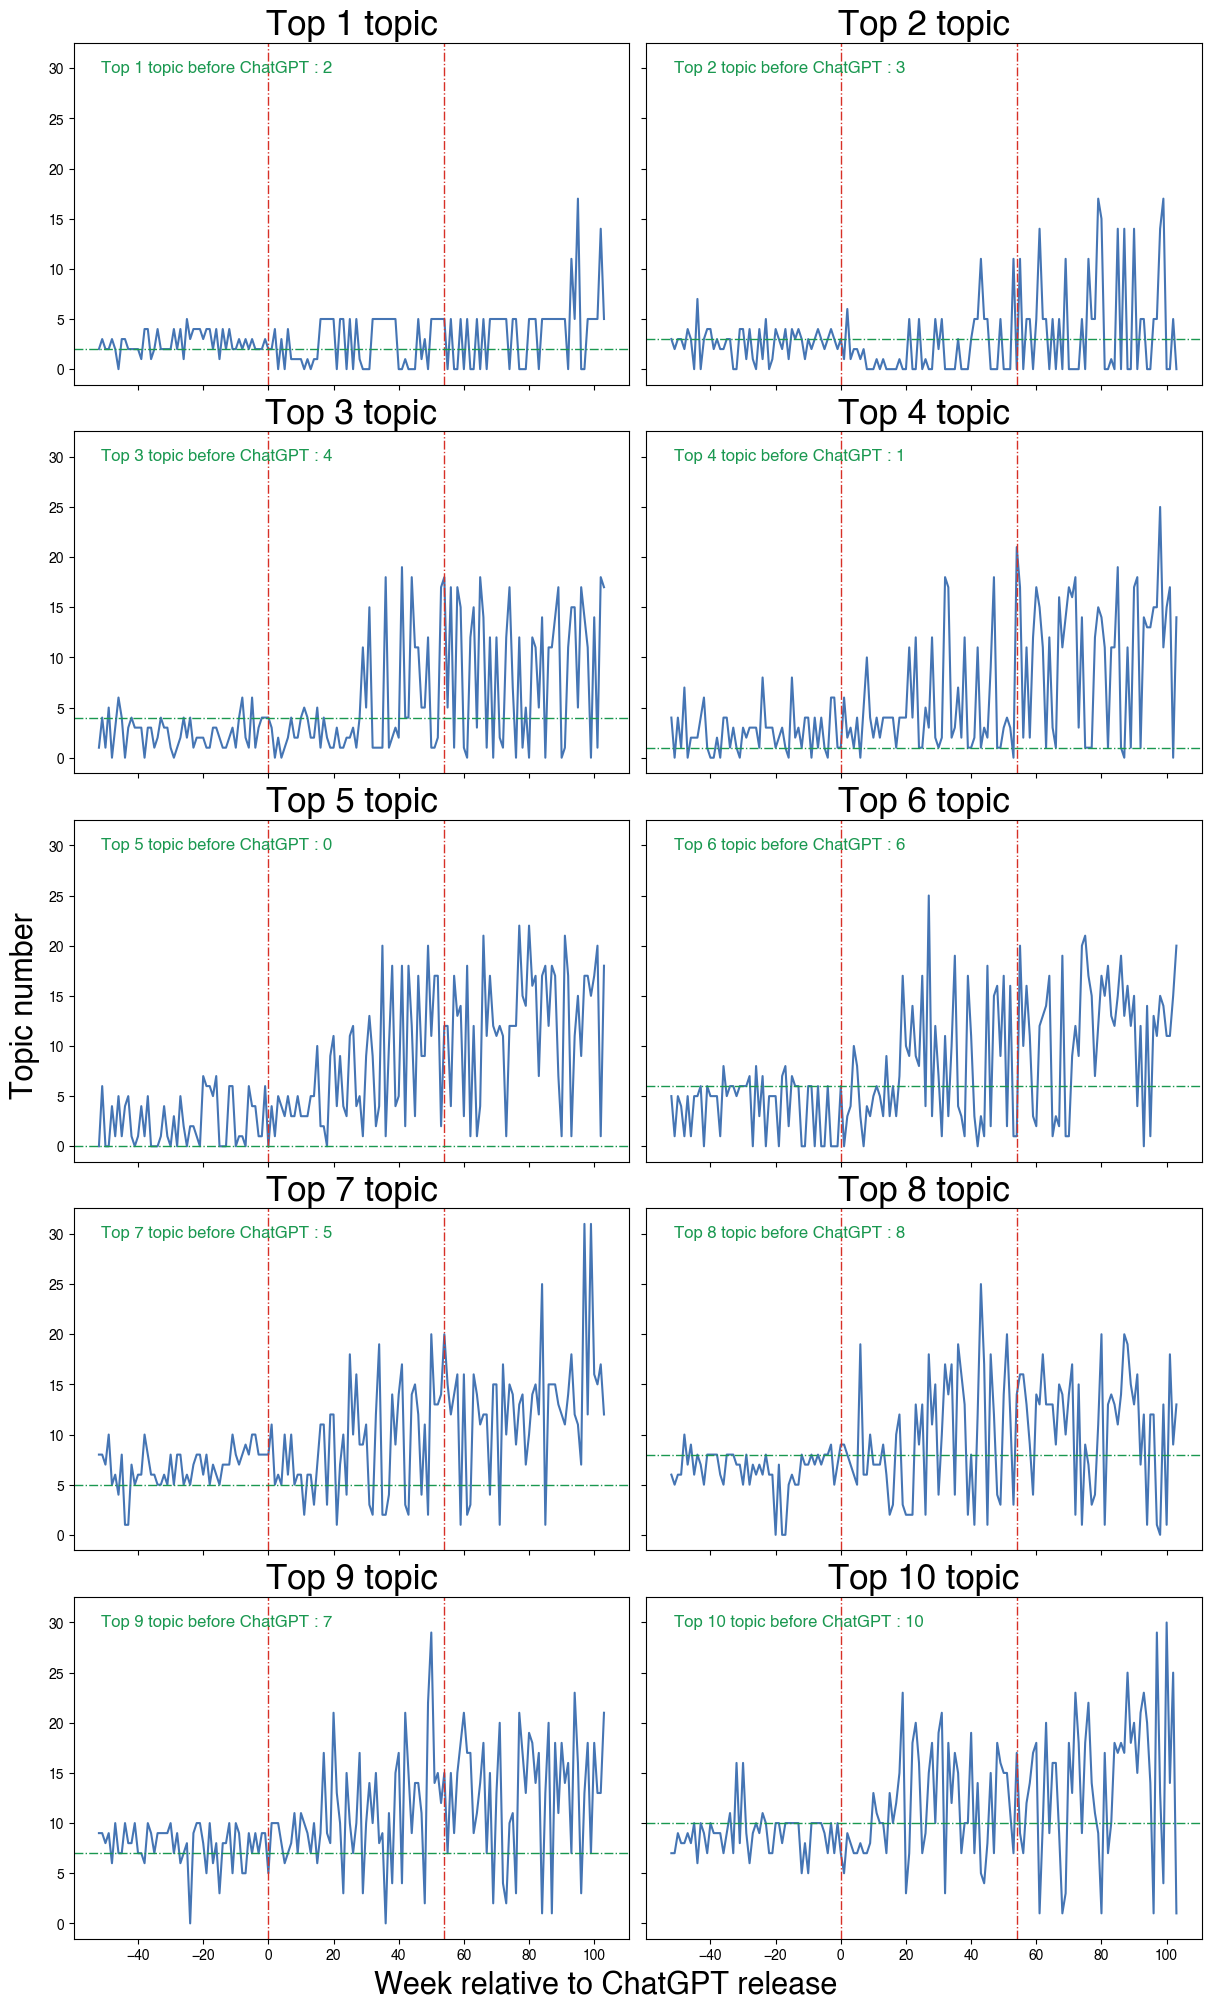

In [ ]:
fig, axs = plt.subplots(5, 2, figsize = (12, 20), constrained_layout=True, sharex=True, sharey=True)
rel_week = list(np.arange(-52, 104))

for i in range(0, 10):
    x = int(i/2)
    y = i%2
    axs[x][y].plot(rel_week, top_rank_dict[i], color ="#4575b4")
    axs[x][y].set_title(f'Top {i+1} topic', fontsize=25)
    axs[x][y].axvline(x=0, color="#d73027" , linestyle='-.', linewidth=1)
    axs[x][y].axvline(x=54, color="#d73027" , linestyle='-.', linewidth=1)
    axs[x][y].axhline(y=top10list[i], color="#1a9850", linestyle='-.', linewidth=1)
    axs[x][y].text(0.05, 0.95, f'Top {i+1} topic before ChatGPT : {top10list[i]}', fontsize=12,
    color="#1a9850",
    ha='left',
    va='top',
    transform=axs[x][y].transAxes
)


fig.supxlabel("Week relative to ChatGPT release", fontsize=22)
fig.supylabel("Topic number", fontsize=22)

Text(0.02, 0.5, 'Topic number')

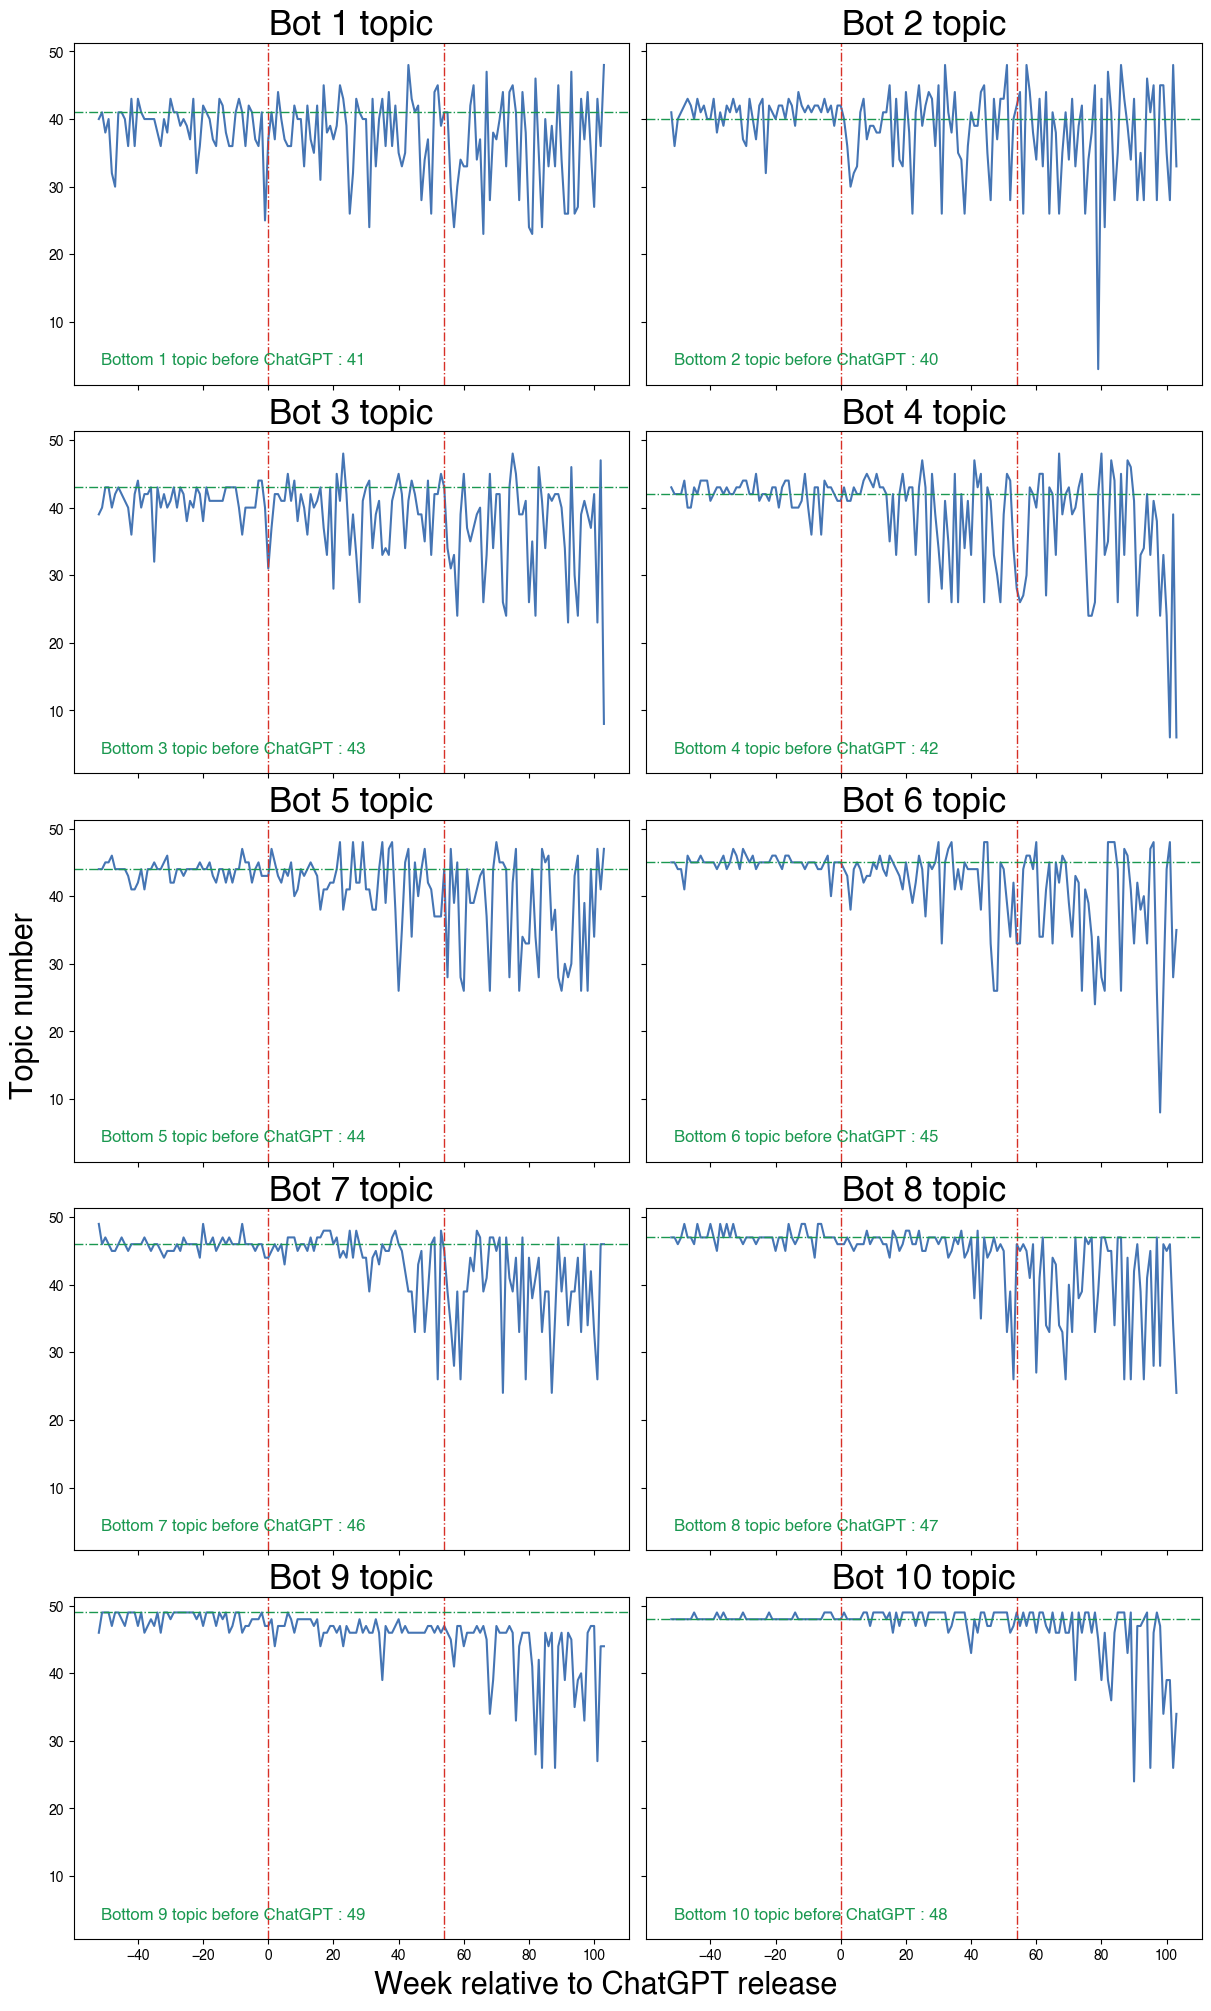

In [26]:
fig, axs = plt.subplots(5, 2, figsize = (12, 20), constrained_layout=True, sharex=True, sharey=True)
rel_week = list(np.arange(-52, 104))

for i in range(0, 10):
    x = int(i/2)
    y = i%2
    axs[x][y].plot(rel_week, bot_rank_dict[i], color ="#4575b4")
    axs[x][y].set_title(f'Bot {i+1} topic', fontsize=25)
    axs[x][y].axvline(x=0, color="#d73027" , linestyle='-.', linewidth=1)
    axs[x][y].axvline(x=54, color="#d73027" , linestyle='-.', linewidth=1)
    axs[x][y].axhline(y=bot10list[i], color="#1a9850", linestyle='-.', linewidth=1)
    axs[x][y].text(0.05, 0.05, f'Bottom {i+1} topic before ChatGPT : {bot10list[i]}', fontsize=12,
    color="#1a9850",
    ha='left',
    va='bottom',
    transform=axs[x][y].transAxes
)


fig.supxlabel("Week relative to ChatGPT release", fontsize=22)
fig.supylabel("Topic number", fontsize=22)

Text(0.02, 0.5, 'Topic number')

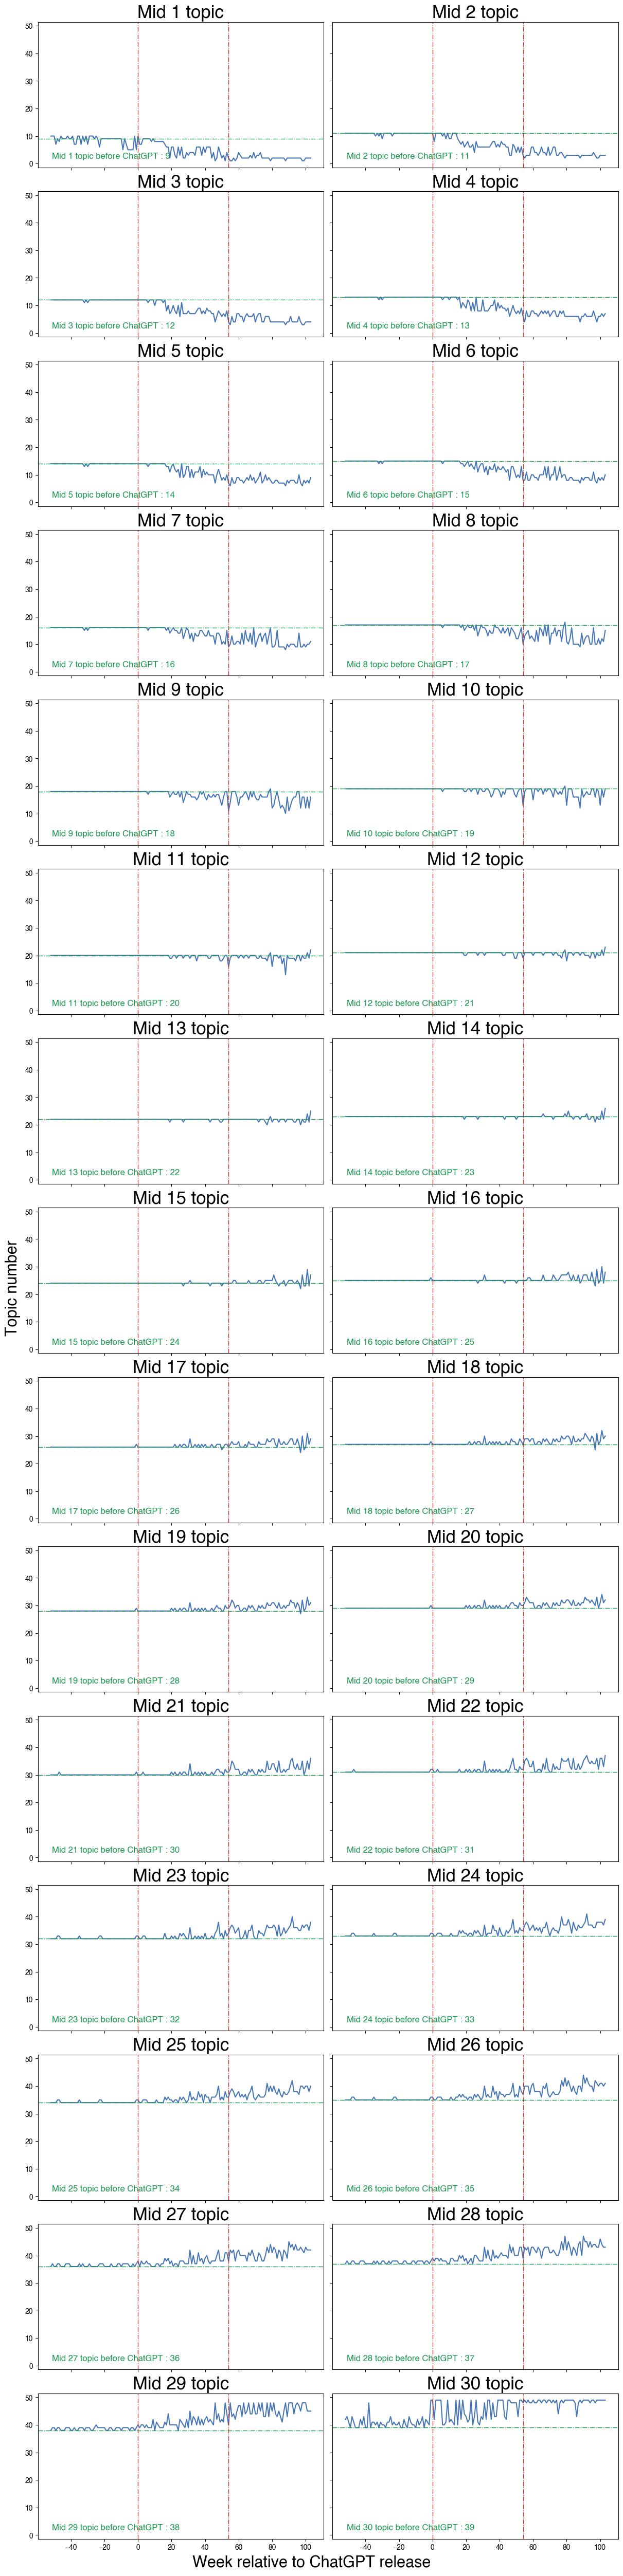

In [31]:
fig, axs = plt.subplots(15, 2, figsize = (12, 50), constrained_layout=True, sharex=True, sharey=True)
rel_week = list(np.arange(-52, 104))

for i in range(0, 30):
    x = int(i/2)
    y = i%2
    axs[x][y].plot(rel_week, mid_rank_dict[i], color ="#4575b4")
    axs[x][y].set_title(f'Mid {i+1} topic', fontsize=25)
    axs[x][y].axvline(x=0, color="#d73027" , linestyle='-.', linewidth=1)
    axs[x][y].axvline(x=54, color="#d73027" , linestyle='-.', linewidth=1)
    axs[x][y].axhline(y=mid10list[i], color="#1a9850", linestyle='-.', linewidth=1)
    axs[x][y].text(0.05, 0.05, f'Mid {i+1} topic before ChatGPT : {mid10list[i]}', fontsize=12,
    color="#1a9850",
    ha='left',
    va='bottom',
    transform=axs[x][y].transAxes
)


fig.supxlabel("Week relative to ChatGPT release", fontsize=22)
fig.supylabel("Topic number", fontsize=22)